In [ ]:
# @title Setup — Run this first
import os

if not os.path.exists('/content/MS_spectra_encoding'):
    !git clone https://github.com/Alexander-Sol/MS_spectra_encoding.git /content/MS_spectra_encoding

%cd /content/MS_spectra_encoding

# Install packages not pre-installed on Colab
!pip install -q pyteomics==4.6.1 spectrum-utils==0.4.2 rapidhash==0.1.0 mmh3

!gdown 1uBQSqXOQduhW9Yy94VRWuV9k3CUR6QbG -O Data/04-17-23_CA_Tryp_HCD_10min-calib.mzML


## 1. Introduction

* **Motivation:**

  * Mass spectrometers collect tens of thousands of individual spectra for each sample that is analyzed.
  * There are too many spectra to analyze by hand, so the proteomics community has relied on computational approaches to data analysis for many years.
  * Exciting research is being done to apply tools from machine-learning (ML) to the analysis of mass spectrometric data.
  * To analyze mass spec data using ML,the first step is to transform spectra into formats that are machine-readable and conducive to the specific types of ML that will be applied.
  * These tutorials will walk through three different ways that mass spectra can be transformed, or encoded, and how each transformation enables different ML methods.
  
* **Learning Goals:**

  * Understand 3 approaches to spectral encoding and different research papers/software tools that use each approach
    * Spectral Hashing for Open Modification Search
    * Positional Encoding of MS2 Spectra for *de novo* peptide sequencing
    * Positional Encoding of 'Augmented Spectra' for *de novo* sequencing in DIA data
  * See how dimensionality reduction and embeddings enable clustering, visualization, and downstream ML tasks.

* **Necessary Background:**

  * To get the most out of this tutorial, you'll need a certain level of familiary with mass spectrometry based proteomics and computational methods used to analyze mass spec proteomics data.
  * If you're unfamiliar with terms like MS1, MS2, or Peptide-Spectrum Match, we recommend the following resources:
    * [An Introduction to Mass Spectrometry-Based Proteomics](https://pubs.acs.org/doi/10.1021/acs.jproteome.2c00838)
      * This excellent review article provides an accesible overview of everything you need to know to understand mass spec proteomics
    * [Lessons in Computational Proteomics](https://biology.byu.edu/sam-payne-lab/data-provider)
      * These lessons show how proteomics data is analyzed using Jupyter notebooks, enabling you to work through

Throughout this tutorial, we'll be using a number of custom functions that we've written to make it easier to demonstrate what's going on. These functions can be found in the util.py file, and examples of how these functions are used can be found below. (A few of these functions were taken from [Lesson 4](https://colab.research.google.com/drive/13WEV58HpkY7f0kFi2BA5ia5p0XZCL3Cq?authuser=1#scrollTo=FYgmwfThBQJJ) of  [Lessons in Computational Proteomics](https://biology.byu.edu/sam-payne-lab/data-provider)).

In [ ]:
if(False):  # --- IGNORE ---
    %%capture
    %pip install pyteomics
    %pip install plotly==5.18.0
    %pip install pandas
    %pip install spectrum_utils==0.4.2
    %pip install scikit-learn
    %pip install rapidhash
    %pip install manim
    %pip install seaborn

In [ ]:
# @title Run this cell to download parent Google drive contents
import spectrum_utils.plot as sup
import spectrum_utils.spectrum as sus
import pyteomics
from pyteomics import mzml, auxiliary
import plotly.io as pio
import plotly.tools as tls
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from rapidhash import rapidhash
from IPython.display import display, Latex
from util import *
import importlib

### 1.1 Overview of Mass Spectrometric Data
#### 1.1.a Example MS1 Spectrum

Shown below is an MS1 spectrum: All ions between 400 and 1500 m/z were collected and analyzed.
If you zoom in. you can see three peaks at 487.3, 487.8, 488.3. These peaks represent three different isotopologues of a peptide.

In [1]:
# The import/reload can be removed once util.py is stable
import util
importlib.reload(util)
from util import *

mzml_path = 'Data/04-17-23_CA_Tryp_HCD_10min-calib.mzML'
get_MS1_object(mzml_path, 5671)

### 1.1 Overview of Mass Spectrometric Data
#### 1.1.b Example MS2 Spectrum

Now, let's look at an MS2 spectrum. This spectrum was collected immediately after the MS1 spectrum. The instrument isolated ions between 486.1 m/z and 488.6 m/z ( including our peptide isotoplogues!), [fragmented them](https://en.wikipedia.org/wiki/Collision-induced_dissociation), and analyzed the resulting fragments.

In [2]:
# Show an the MS2 scan
ms2_spectrum_unannotated = get_MS2_object(mzml_path, 5672)
plot_MS2(ms2_spectrum_unannotated, title="MS2 Spectrum - Scan 5672")

### 1.2 Overview of Database Search

Need to add a broad overview of how database search works
Protein database --> In silico digestion --> Matching fragment
Use function for generating ion ladders, demonstrate theoretical fragment masses
Match them to the spectrum from above, show annotated spectrum


The data file contains a segment of a mass spec run analyzing peptides from [bovine carbonic anhydrase](https://www.uniprot.org/uniprotkb/P00921/entry).

One of the peptides that is produced if you use [trypsin](https://en.wikipedia.org/wiki/Trypsin) to digest carbonic anhydrase is *'VLDALDSIK'*.


*Demonstrate ion ladder here*
*Explain how ion ladder corresponds to annotate spectrum*

On the left, we show the unannotated mass spectrum. On the right, we show the same spectrum, this time highlighting peaks from fragment ions that were matched to the peptide *'VLDALDSIK'*.

(Can probably get rid of this guy)

In [ ]:
# Show an MS1 and an MS2

mzml_path = 'Data/04-17-23_CA_Tryp_HCD_10min-calib.mzML'
ms2_spectrum_annotated = get_MS2_object(mzml_path, 5672, peptide = 'VLDALDSIK')
plot_MS2(ms2_spectrum_annotated)

---
## Appendix: Function Definitions

Below are the definitions of key utility functions used throughout this notebook. They live in `util.py` and are imported at the top, so you don't need to run these cells for the notebook to work — they're here purely for reference. Feel free to skip this section if you're not interested in the implementation details.

In [ ]:
import spectrum_utils.plot as sup
import spectrum_utils.spectrum as sus
import pyteomics
from pyteomics import mzml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.tools as tls
from util import extract_scan_number

In [ ]:
# title="Constants"

AMINO_ACID_DICT = {'A': 71.037114, 'R':156.101111 , 'N': 114.042927,
        'D': 115.026943, 'C': 103.009185, 'E': 129.042593,
        'Q' : 128.058578, 'G': 57.021464, 'H': 137.058912,
        'I': 113.084064, 'L': 113.084064, 'K': 128.094963,
        'M' : 131.040485, 'F':  147.068414, 'P':  97.052764,
        'S': 87.032028, 'T': 101.047679, 'U': 150.95363,
        'W': 186.079313, 'Y': 163.06332, 'V': 99.068414
        }

PROTON_MASS = 1.007276466812
HYDROGEN_MASS = 1.00784
OXYGEN_MASS = 15.994915

In [ ]:
def get_MS2_object(mzml_path, scan, peptide=None):
    su_spectrum = None
    with pyteomics.mzml.read(mzml_path) as spectra:
        for spectrum in spectra:
            scanNumber = extract_scan_number(spectrum['id'])
            if scanNumber == scan:
                spectrum_id = spectrum['id']
                mz = spectrum['m/z array']
                intensity = spectrum['intensity array']
                retention_time = spectrum['scanList']['scan'][0]['scan start time']
                precursor_mz = spectrum['precursorList']['precursor'][0]['isolationWindow']['isolation window target m/z']
                precursor_charge = int(spectrum['precursorList']['precursor'][0]['selectedIonList']['selectedIon'][0]['charge state'])

                su_spectrum = sus.MsmsSpectrum(spectrum_id, precursor_mz, precursor_charge, mz, intensity, retention_time=retention_time)

                # Filter low-intensity peaks, remove precursor, and root-scale intensities
                su_spectrum = (su_spectrum.filter_intensity(0.05, 50)
                               .remove_precursor_peak(fragment_tol_mass=10, fragment_tol_mode='ppm')
                               .scale_intensity('root'))
                break
    if su_spectrum:
        fragment_tol_mass = 10
        fragment_tol_mode = 'ppm'
        if peptide:
            su_spectrum = su_spectrum.annotate_proforma(peptide, fragment_tol_mass, fragment_tol_mode, ion_types='by', max_ion_charge=2)
    return su_spectrum

In [3]:
# Example: retrieve scan 5672, annotated with peptide VLDALDSIK
# This cell might take a while the first time it is run, as it needs to read through the mzML file to find the correct scan.
# Subsequent runs will be faster as the mzML file will be cached in memory.

example_ms2 = get_MS2_object('Data/04-17-23_CA_Tryp_HCD_10min-calib.mzML', 5672, peptide='VLDALDSIK')
print(f"identifier: {example_ms2.identifier}")
print(f"precursor_mz: {example_ms2.precursor_mz}")
print(f"precursor_charge: {example_ms2.precursor_charge}")
print(f"retention_time: {example_ms2.retention_time}")
print(f"mz (first 5 peaks): {example_ms2.mz[:5]}")
print(f"intensity (first 5 peaks): {example_ms2.intensity[:5]}")

identifier: controllerType=0 controllerNumber=1 scan=5672
precursor_mz: 487.25412965978245
precursor_charge: 2
retention_time: 13.307233810424805
mz (first 5 peaks): [129.10279475 147.11338918 185.16559948 186.16882696 213.16060227]
intensity (first 5 peaks): [2174.818  3145.84   9230.925  2883.7764 4380.564 ]


In [ ]:
def make_ion_ladder(peptide, aa_mass=None):
    """Generate b and y ion ladders for a given peptide sequence."""
    aa_mass = aa_mass or AMINO_ACID_DICT
    b_ions = {}
    y_ions = {}

    # Generate b-ions (N-terminal fragments)
    b_mass_current = 0
    b_ion = ''
    for aa in peptide:
        b_ion += aa
        if b_ion != peptide:
            b_mass_current += aa_mass[aa]
            b_ions[b_ion] = b_mass_current + PROTON_MASS

    # Generate y-ions (C-terminal fragments)
    y_mass_current = HYDROGEN_MASS + OXYGEN_MASS + PROTON_MASS
    y_ion = ''
    for aa in peptide[::-1]:
        y_ion += aa
        if y_ion[::-1] != peptide:
            y_mass_current += aa_mass[aa]
            y_ions[y_ion[::-1]] = y_mass_current + PROTON_MASS

    data = {
        'b#': [b + 1 for b in range(len(peptide) - 1)],
        'b_ion_m/z': [b_ions[k] for k in b_ions],
        'b_ion_sequence': list(b_ions.keys()),
        'y_ion_sequence': list(y_ions.keys())[::-1],
        'y_ion_m/z': list(y_ions.values())[::-1],
        'y#': [len(peptide) - i - 1 for i in range(len(peptide) - 1)]
    }
    df = pd.DataFrame(data)
    df = df.style.set_properties(
        subset=['b_ion_sequence'], **{'text-align': 'left'}
    ).format({
        'b_ion_m/z': '{:,.2f}',
        'y_ion_m/z': '{:,.2f}'
    }).set_table_styles([{
        'selector': 'thead th',
        'props': [('vertical-align', 'bottom'), ('text-align', 'left')]
    }])
    return df

In [4]:
# Example: generate the ion ladder for peptide VLDALDSIK
make_ion_ladder('VLDALDSIK')

,b#,b_ion_m/z,b_ion_sequence,y_ion_sequence,y_ion_m/z,y#
0,1,100.08,V,LDALDSIK,874.49,8
1,2,213.16,VL,DALDSIK,761.40,7
2,3,328.19,VLD,ALDSIK,646.38,6
3,4,399.22,VLDA,LDSIK,575.34,5
4,5,512.31,VLDAL,DSIK,462.26,4
5,6,627.33,VLDALD,SIK,347.23,3
6,7,714.37,VLDALDS,IK,260.20,2
7,8,827.45,VLDALDSI,K,147.11,1


In [ ]:
def plot_MS2(ms2_spectrum, title=None, parent=None):
    """Plot an MS2 spectrum. Converts to interactive Plotly if available,
    otherwise falls back to a static matplotlib figure."""
    ax = sup.spectrum(ms2_spectrum)
    if tls is not None and hasattr(tls, 'mpl_to_plotly'):
        try:
            plotly_fig = tls.mpl_to_plotly(ax.figure)
            plotly_fig['layout']['plot_bgcolor'] = 'white'
            plotly_fig['layout']['xaxis']['showline'] = True
            plotly_fig['layout']['xaxis']['linecolor'] = 'black'
            plotly_fig['layout']['xaxis']['linewidth'] = 2
            plotly_fig['layout']['yaxis']['linecolor'] = 'black'
            plotly_fig['layout']['yaxis']['linewidth'] = 2
            plotly_fig['layout']['yaxis']['title'] = 'Relative Intensity'
            if title:
                plotly_fig['layout']['title'] = title
            elif ms2_spectrum and hasattr(ms2_spectrum, 'identifier'):
                plotly_fig['layout']['title'] = f'MS2 Spectrum - Scan {extract_scan_number(ms2_spectrum.identifier)}'
            else:
                plotly_fig['layout']['title'] = 'MS2 Spectrum'
            plotly_fig.update_yaxes(range=[0, 1.05])
            return plotly_fig
        except Exception:
            pass
    # Fallback: show the matplotlib figure directly
    if title:
        ax.set_title(title)
    ax.figure.tight_layout()
    plt.show()
    return ax.figure

In [5]:
# Example: plot the annotated MS2 spectrum from scan 5672
plot_MS2(example_ms2, title='MS2 Spectrum - Scan 5672')

In [ ]:
def plot_theoretical_ions(b_mz, y_mz, peptide):
    """Plot theoretical b- and y-ions as a stem plot.
    Ion heights are scaled so earlier ions (b1/y1) appear tallest."""
    max_height, min_height = 0.9, 0.1
    b_heights = np.linspace(max_height, min_height, len(b_mz))
    y_heights = np.linspace(max_height, min_height, len(y_mz))

    fig, ax = plt.subplots(figsize=(10, 4), dpi=100)
    ax.vlines(b_mz, 0, b_heights, colors='#1976D2', linewidth=1.5, label='b-ions')
    ax.vlines(y_mz, 0, y_heights, colors='#D32F2F', linewidth=1.5, label='y-ions')

    ax.set_ylim(0, 1.1)
    ax.set_xlabel('m/z')
    ax.set_ylabel('Intensity (scaled)')
    ax.set_title(f'Theoretical ions for {peptide}')
    ax.legend(loc='upper center')
    ax.grid(True, axis='y', alpha=0.25)

    for i, (x, h) in enumerate(zip(b_mz, b_heights), start=1):
        ax.text(x, h + 0.02, f'b{i}', rotation=90, ha='center', va='bottom', fontsize=8)
    for i, (x, h) in enumerate(zip(y_mz, y_heights), start=1):
        j = len(y_mz) - i + 1
        ax.text(x, h + 0.02, f'y{j}', rotation=90, ha='center', va='bottom', fontsize=8)

    plt.show()

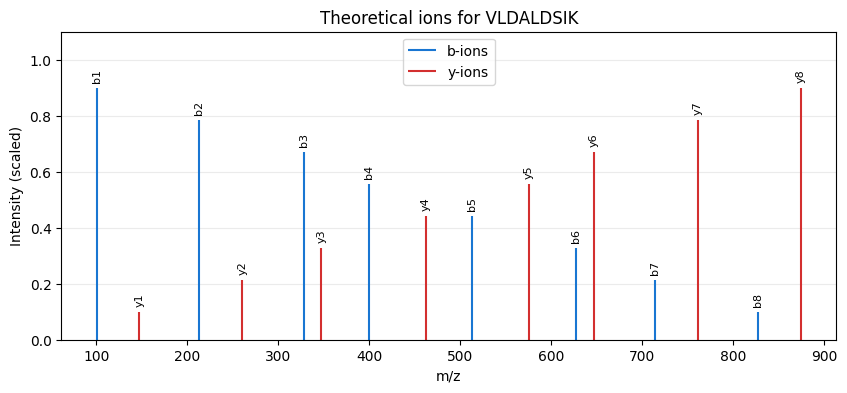

In [6]:
# Example: plot theoretical ions for VLDALDSIK
# make_ion_ladder returns a Styler; use .data to access the underlying DataFrame
ladder = make_ion_ladder('VLDALDSIK')
b_mz = ladder.data['b_ion_m/z'].values
y_mz = ladder.data['y_ion_m/z'].values
plot_theoretical_ions(b_mz, y_mz, 'VLDALDSIK')